# KL-IG Evaluation Notebook

**Methods compared:**
| Method | Baseline / Technique | Path |
|--------|---------------------|------|
| KL-IG (Linear) | N(0, I) prior | Distribution-space (mu, logvar) |
| IDG | Input × Gradient | Direct gradient × input |
| ExpGrad | Expected Gradients (random backgrounds) | GradientShap with stdev=0 |
| IG-zero | Integrated Gradients (zero baseline) | Pixel-space linear |
| SmoothGrad | Noise-averaged Saliency | Gaussian perturbation |
| Vanilla Grad | Raw gradient | Single backprop |

**Evaluation metrics:**
| Category | Metric | What it measures |
|----------|--------|------------------|
| **Faithfulness** | Insertion / Deletion | Does masking by attribution order change predictions? |
| **Faithfulness** | Sensitivity-n (PCC) | Correlation between attr sum and output change for random subsets |
| **Faithfulness** | Completeness & Soundness | Does salient region suffice / non-salient region not matter? |
| **Faithfulness** | BEExAI Faithfulness (IROF) | Iterative removal of features by attribution rank |
| **Robustness** | Perturbation sigma | Attribution stability under input noise |
| **Robustness** | BEExAI Robustness | Stability under small input perturbations |
| **Complexity** | BEExAI Complexity | Entropy-based concentration of attributions |
| **Sensitivity** | Occlusion correlation | Agreement with occlusion importance |

## 1. Imports & Device

In [3]:
!git clone https://github.com/Shameen5375/KLIG_V1.git 2>/dev/null || echo "Repo already cloned"
%cd KLIG_V1

/content/KLIG_V1/KLIG_V1


In [ ]:
import sys, math, warnings
from pathlib import Path
from collections import defaultdict

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
from PIL import Image
from torchvision.models import ResNet50_Weights, resnet50
from scipy import stats
from tqdm.notebook import tqdm

ROOT = Path.cwd()
if not (ROOT / "klig").exists():
    ROOT = ROOT / "infocube-main"
sys.path.append(str(ROOT))

from klig.image.attribution import ImageAttributor
from klig.image.stopping import find_sigma_stop
from klig.compare.captum_baselines import (
    run_ig, run_smoothgrad, run_expected_gradients, _absmax_collapse,
)
from klig.image.viz import _attr_to_rgb
from captum.attr import IntegratedGradients, Saliency

warnings.filterwarnings("ignore", category=UserWarning)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"Root:   {ROOT}")

## 2. Download Test Images & Configure

In [7]:
!pip install -q captum

In [20]:
!mkdir -p imagesv1

# Download diverse images (different classes so predictions differ)
!wget -q "https://upload.wikimedia.org/wikipedia/commons/2/26/YellowLabradorLooking_new.jpg" -O images/dog.jpg
!wget -q "https://upload.wikimedia.org/wikipedia/commons/4/4d/Cat_November_2010-1a.jpg"       -O images/cat.jpg
!wget -q "https://upload.wikimedia.org/wikipedia/commons/thumb/3/3a/Cat03.jpg/1200px-Cat03.jpg" -O images/tabby.jpg

!ls -lh images/

total 3.0M
-rw-r--r-- 1 root root 2.8M Oct  9  2014 cat.jpg
-rw-r--r-- 1 root root  82K Oct  9  2014 dog.jpg
-rw-r--r-- 1 root root 211K Apr 25  2025 tabby.jpg


In [ ]:
# ── Collect image paths ──
from pathlib import Path

IMG_DIR = Path("/content/KLIG_V1/KLIG_V1/images")
IMAGE_PATHS = sorted(list(IMG_DIR.glob("*.jpg")))

# ── Hyperparameters ──
N_STEPS       = 50        # KL-IG integration steps
N_SAMPLES     = 10        # KL-IG MC samples per step
SIGMA_FINAL   = 1 / 256   # KL-IG default final sigma
ADAPTIVE_SIGMA = True     # use binary-search sigma_stop

IG_STEPS      = 50        # IG steps
BLUR_SIGMA    = 16.0      # Gaussian blur sigma (for blur substrate)
BLUR_KERNEL   = 51        # kernel size (odd)
SG_SAMPLES    = 50        # SmoothGrad noise samples
EG_SAMPLES    = 50        # Expected Gradients samples

N_INSERTION_STEPS   = 100
N_ROBUSTNESS_RUNS   = 5
PERTURBATION_SIGMAS = [0.01, 0.02, 0.05, 0.1, 0.2]
OCCLUSION_PATCH     = 14
OCCLUSION_STRIDE    = 7
CLIP_PCT            = 99.0

# ── Method list (order matches the comparison figure) ──
methods = ["KL-IG", "IDG", "ExpGrad", "IG-zero", "SmoothGrad", "Vanilla Grad"]

# ── ImageNet normalization ──
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
TRANSFORM = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

COLORS = {
    "KL-IG":         "#2E8B57",
    "IDG":           "#E07B39",
    "ExpGrad":       "#DC143C",
    "IG-zero":       "#7B68EE",
    "SmoothGrad":    "#1E90FF",
    "Vanilla Grad":  "#8B4513",
}
print("\nConfig OK.")

## 3. Helper Functions

In [ ]:
# ── Model ──
def load_model():
    weights = ResNet50_Weights.IMAGENET1K_V2
    model = resnet50(weights=weights).to(DEVICE).eval()
    return model, weights.meta["categories"]

# ── Image I/O ──
def load_image(path):
    img = Image.open(str(path)).convert("RGB")
    return TRANSFORM(img).unsqueeze(0).to(DEVICE)

def denormalize(x):
    mean = torch.tensor(IMAGENET_MEAN, device=x.device).view(-1, 1, 1)
    std  = torch.tensor(IMAGENET_STD,  device=x.device).view(-1, 1, 1)
    if x.dim() == 4:
        mean, std = mean.unsqueeze(0), std.unsqueeze(0)
    return (x * std + mean).clamp(0, 1)

def predict_topk(model, x, k=5):
    with torch.no_grad():
        probs = model(x).softmax(-1)[0]
        top_p, top_i = probs.topk(k)
    cats = ResNet50_Weights.IMAGENET1K_V2.meta["categories"]
    return [(cats[int(i)], float(p)) for i, p in zip(top_i, top_p)], top_i.tolist()

# ── Blur baseline (used as substrate in evaluation metrics) ──
def make_blur_baseline(x, kernel_size=BLUR_KERNEL, sigma=BLUR_SIGMA):
    coords = torch.arange(kernel_size, dtype=torch.float32, device=x.device) - kernel_size // 2
    k1d = torch.exp(-0.5 * (coords / sigma) ** 2)
    k1d = k1d / k1d.sum()
    kh = k1d.view(1, 1, -1, 1).expand(3, -1, -1, -1)
    kw = k1d.view(1, 1, 1, -1).expand(3, -1, -1, -1)
    pad = kernel_size // 2
    out = F.conv2d(x, kh, padding=(pad, 0), groups=3)
    return F.conv2d(out, kw, padding=(0, pad), groups=3)

# ── Background set for Expected Gradients ──
def make_eg_background(x, n=50):
    return torch.randn(n, *x.squeeze(0).shape, device=x.device)

# ────────────────────────────────────────────
# 6 Attribution Methods (each returns (H,W) map)
# ────────────────────────────────────────────

def compute_klig(model, x, target):
    sf = SIGMA_FINAL
    if ADAPTIVE_SIGMA:
        sf = max(find_sigma_stop(model, x, target=target, tau=0.95), 1.0 / 256.0)
    attr = ImageAttributor(model=model, n_steps=N_STEPS, n_samples=N_SAMPLES,
                           sigma_final=sf, device=DEVICE)
    return attr.attribute(x, target=target, show_progress=False)

def compute_ig_zero(model, x, target):
    """IG with zero (black) baseline."""
    return run_ig(model, x, target, n_steps=IG_STEPS)

def compute_idg(model, x, target):
    """Input x Gradient (Shrikumar et al.)"""
    x_inp = x.clone().requires_grad_(True)
    out = model(x_inp)
    out[0, target].backward()
    grad = x_inp.grad.detach()
    attr = x_inp.detach() * grad
    return _absmax_collapse(attr)

def compute_expgrad(model, x, target):
    """Expected Gradients (Erion et al.) via GradientShap."""
    bg = make_eg_background(x, n=EG_SAMPLES)
    return run_expected_gradients(model, x, target, background=bg, n_samples=EG_SAMPLES)

def compute_smoothgrad(model, x, target):
    """SmoothGrad (Smilkov et al.)"""
    return run_smoothgrad(model, x, target, n_samples=SG_SAMPLES)

def compute_vanilla_grad(model, x, target):
    """Plain gradient (Simonyan et al. 2014)"""
    sal = Saliency(model)
    attr = sal.attribute(x, target=target, abs=False)
    return _absmax_collapse(attr.detach())

# ── Dispatch table for reuse in eval cells ──
COMPUTE_FN = {
    "KL-IG":         lambda m, x, t: compute_klig(m, x, t).attr_map("absmax"),
    "IDG":           compute_idg,
    "ExpGrad":       compute_expgrad,
    "IG-zero":       compute_ig_zero,
    "SmoothGrad":    compute_smoothgrad,
    "Vanilla Grad":  compute_vanilla_grad,
}

def compute_all(model, x, target):
    """Returns (dict of method->(H,W) maps, klig_result)."""
    klig_res = compute_klig(model, x, target)
    maps = {"KL-IG": klig_res.attr_map("absmax")}
    for name in methods:
        if name == "KL-IG":
            continue
        maps[name] = COMPUTE_FN[name](model, x, target)
    return maps, klig_res

print("Helpers ready -- 6 methods: " + ", ".join(methods))

## 4. Load Model & All Images

In [26]:
model, imagenet_labels = load_model()
print(f"Model: ResNet50 ({sum(p.numel() for p in model.parameters())/1e6:.1f}M params)\n")

# Load each image independently and predict
images = {}
for path in IMAGE_PATHS:
    x_i = load_image(path)                       # (1,3,224,224) -- loaded from THIS file
    preds_i, idx_i = predict_topk(model, x_i)    # predictions for THIS image
    images[path.stem] = dict(path=path, x=x_i, preds=preds_i,
                             top_idx=idx_i, target=idx_i[0])

# Show gallery with per-image predictions
n = len(images)


Model: ResNet50 (25.6M params)



In [ ]:
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
if n == 1: axes = [axes]
for ax, (name, d) in zip(axes, images.items()):
    ax.imshow(denormalize(d["x"][0]).cpu().permute(1, 2, 0).numpy())
    ax.set_title(f"{name}\n{d['preds'][0][0]} ({d['preds'][0][1]:.1%})", fontsize=9)
    ax.axis("off")
plt.suptitle("Loaded Images & Top-1 Predictions", fontweight="bold")
plt.tight_layout(); plt.show()

# Print full top-5 per image
for name, d in images.items():
    print(f"\n{name} -> target class {d['target']}:")
    for lab, p in d["preds"]:
        print(f"  {lab}: {p:.4f}")

## 5. Compute Attributions (All Images x All Methods)

In [ ]:
results = {}

for name, d in images.items():
    print(f"[{name}] computing attributions...")
    maps, klig_res = compute_all(model, d["x"], d["target"])
    results[name] = {"maps": maps, "klig": klig_res, **d}
    print(f"  KL-IG completeness = {klig_res._r.completeness_check():.4f}")

# ── Grid: rows = images, cols = [Input, KL-IG, IDG, ExpGrad, IG-zero, SmoothGrad, Vanilla Grad] ──
n_imgs = len(results)
n_cols = 1 + len(methods)
fig, axes = plt.subplots(n_imgs, n_cols, figsize=(3.2 * n_cols, 3.5 * n_imgs), squeeze=False)

for row, (name, r) in enumerate(results.items()):
    axes[row][0].imshow(denormalize(r["x"][0]).cpu().permute(1, 2, 0).numpy())
    axes[row][0].set_title(f"{name}\n{r['preds'][0][0]}\n({r['preds'][0][1]:.1%})", fontsize=8)
    axes[row][0].axis("off")
    for col, method in enumerate(methods):
        amap = r["maps"][method]
        axes[row][col+1].imshow(_attr_to_rgb(amap, clip_percentile=CLIP_PCT))
        axes[row][col+1].set_title(method if row == 0 else "", fontsize=9)
        axes[row][col+1].axis("off")

fig.suptitle("Attribution Maps: All Images x All Methods", fontweight="bold", fontsize=13)
plt.tight_layout(); plt.show()

---
## 6. Faithfulness: Insertion / Deletion Curves

In [ ]:
def insertion_deletion(model, x, attr_map, target, n_steps=N_INSERTION_STEPS):
    H, W = attr_map.shape
    n_pix = H * W
    order = attr_map.detach().cpu().abs().view(-1).argsort(descending=True)
    substrate = make_blur_baseline(x)
    pps = max(1, n_pix // n_steps)

    ins_img, del_img = substrate.clone(), x.clone()
    ins_scores, del_scores = [], []

    with torch.no_grad():
        ins_scores.append(model(ins_img).softmax(-1)[0, target].item())
        del_scores.append(model(del_img).softmax(-1)[0, target].item())
        for step in range(1, n_steps + 1):
            s, e = (step-1)*pps, min(step*pps, n_pix)
            if s >= n_pix:
                ins_scores.append(ins_scores[-1]); del_scores.append(del_scores[-1]); continue
            idx = order[s:e]
            hi, wi = idx // W, idx % W
            ins_img[0, :, hi, wi] = x[0, :, hi, wi]
            del_img[0, :, hi, wi] = substrate[0, :, hi, wi]
            ins_scores.append(model(ins_img).softmax(-1)[0, target].item())
            del_scores.append(model(del_img).softmax(-1)[0, target].item())

    ins, dl = np.array(ins_scores), np.array(del_scores)
    return dict(insertion=ins, deletion=dl,
                ins_auc=np.trapz(ins, dx=1/n_steps),
                del_auc=np.trapz(dl, dx=1/n_steps))

# Run for every image
id_all = {}
for name, r in results.items():
    id_all[name] = {}
    for method, amap in r["maps"].items():
        id_all[name][method] = insertion_deletion(model, r["x"], amap, r["target"])

# Plot per image
frac = np.linspace(0, 1, N_INSERTION_STEPS + 1)
for name in results:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for method, res in id_all[name].items():
        axes[0].plot(frac, res["insertion"], label=f'{method} (AUC={res["ins_auc"]:.3f})',
                     color=COLORS[method], lw=2)
        axes[1].plot(frac, res["deletion"], label=f'{method} (AUC={res["del_auc"]:.3f})',
                     color=COLORS[method], lw=2)
    axes[0].set(title=f"{name}: Insertion (higher=better)", xlabel="frac inserted", ylabel="P(target)")
    axes[1].set(title=f"{name}: Deletion (lower=better)",  xlabel="frac deleted",  ylabel="P(target)")
    for a in axes: a.legend(fontsize=8); a.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

---
## 7. Faithfulness: Sensitivity-n (Ancona et al., ICLR 2018)

For random subsets of **n** pixel-features, compute the **Pearson Correlation Coefficient (PCC)** between:
- $\sum_{i \in S} a_i$ — the sum of attributions in the subset
- $f(x) - f(x_{\setminus S})$ — the actual output change when those features are removed (set to baseline)

Sweep $n$ from small to large fractions of the total pixels. A faithful attribution should show **high PCC** across all $n$ values — meaning the attributions correctly predict which features matter most.

> **Reference:** Ancona et al., *"Towards better understanding of gradient-based attribution methods for Deep Neural Networks"*, ICLR 2018.

In [ ]:
def sensitivity_n(model, x, attr_map, target, n_fractions=None, n_subsets=100):
    """
    Sensitivity-n: PCC between sum(attr[subset]) and actual output change
    when subset features are removed (replaced with blur baseline).

    Returns dict with 'fractions', 'pccs' arrays.
    """
    if n_fractions is None:
        n_fractions = [0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.8]

    H, W = attr_map.shape
    n_pix = H * W
    attr_flat = attr_map.detach().cpu().numpy().ravel()
    baseline = make_blur_baseline(x)

    with torch.no_grad():
        f_orig = model(x).softmax(-1)[0, target].item()

    pccs = []
    for frac in n_fractions:
        n = max(1, int(frac * n_pix))
        attr_sums = []
        output_diffs = []

        for _ in range(n_subsets):
            subset = np.random.choice(n_pix, size=n, replace=False)

            # Sum of attributions in subset
            attr_sums.append(attr_flat[subset].sum())

            # Actual output change: replace subset pixels with baseline
            x_masked = x.clone()
            hi, wi = subset // W, subset % W
            x_masked[0, :, hi, wi] = baseline[0, :, hi, wi]

            with torch.no_grad():
                f_masked = model(x_masked).softmax(-1)[0, target].item()
            output_diffs.append(f_orig - f_masked)

        # Pearson correlation
        r, _ = stats.pearsonr(attr_sums, output_diffs)
        pccs.append(r if not np.isnan(r) else 0.0)

    return {"fractions": np.array(n_fractions), "pccs": np.array(pccs)}

# ── Run Sensitivity-n for all images ──
sens_n_all = {}
for name, r in results.items():
    print(f"[{name}] Sensitivity-n...")
    sens_n_all[name] = {}
    for method, amap in r["maps"].items():
        sens_n_all[name][method] = sensitivity_n(model, r["x"], amap, r["target"])

# ── Plot PCC curves ──
fig, axes = plt.subplots(1, len(results), figsize=(6 * len(results), 5), squeeze=False)
for col, (name, img_res) in enumerate(sens_n_all.items()):
    ax = axes[0][col]
    for method, sn in img_res.items():
        mean_pcc = sn["pccs"].mean()
        ax.plot(sn["fractions"], sn["pccs"], "o-", label=f"{method} (avg={mean_pcc:.3f})",
                color=COLORS[method], lw=2, ms=5)
    ax.set(xlabel="Fraction n / total pixels", ylabel="PCC",
           title=f"{name}: Sensitivity-n", ylim=(-0.3, 1.05))
    ax.axhline(0, color="gray", ls="--", alpha=0.3)
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.suptitle("Sensitivity-n: PCC between attr sum and output change (higher = more faithful)",
             fontweight="bold", fontsize=12)
plt.tight_layout(); plt.show()

# Average PCC across all fractions and images
avg_sens = {m: np.mean([sens_n_all[n][m]["pccs"].mean() for n in sens_n_all]) for m in methods}
print("\nAverage Sensitivity-n PCC:")
for m in methods:
    print(f"  {m}: {avg_sens[m]:.4f}")

---
## 8. Faithfulness: Completeness & Soundness (arXiv:2211.02912)

**Completeness:** Does the salient region contain enough information to preserve the prediction?
- Keep only the top-k% attributed pixels (replace rest with baseline) and check if model prediction is preserved.
- Metric: probability of target class on the masked image.

**Soundness:** Does the saliency map avoid highlighting unnecessary regions?
- Remove the top-k% attributed pixels (replace with baseline) and check if the prediction drops.
- Metric: drop in target class probability when salient pixels are removed.

A good attribution is both **complete** (keeping salient region preserves prediction) and **sound** (removing salient region destroys prediction).

> **Reference:** Rao et al., *"Towards Better Understanding Attribution Methods"*, arXiv:2211.02912, CVPR 2023.

In [ ]:
def completeness_soundness(model, x, attr_map, target, k_percents=None):
    """
    Completeness: keep top-k% attributed pixels, replace rest with baseline.
    Soundness:    remove top-k% attributed pixels, replace with baseline.

    Returns dict with 'k_percents', 'completeness' (probs), 'soundness' (prob drops).
    """
    if k_percents is None:
        k_percents = [1, 2, 5, 10, 20, 30, 50, 70, 90]

    H, W = attr_map.shape
    n_pix = H * W
    order = attr_map.detach().cpu().abs().view(-1).argsort(descending=True)
    baseline = make_blur_baseline(x)

    with torch.no_grad():
        f_orig = model(x).softmax(-1)[0, target].item()

    completeness_scores = []
    soundness_scores = []

    for k_pct in k_percents:
        k = max(1, int(k_pct / 100 * n_pix))
        top_idx = order[:k]
        top_hi, top_wi = top_idx // W, top_idx % W

        # Completeness: keep only top-k%, replace rest with baseline
        x_keep = baseline.clone()
        x_keep[0, :, top_hi, top_wi] = x[0, :, top_hi, top_wi]
        with torch.no_grad():
            p_keep = model(x_keep).softmax(-1)[0, target].item()
        completeness_scores.append(p_keep)

        # Soundness: remove top-k%, keep rest
        x_remove = x.clone()
        x_remove[0, :, top_hi, top_wi] = baseline[0, :, top_hi, top_wi]
        with torch.no_grad():
            p_remove = model(x_remove).softmax(-1)[0, target].item()
        soundness_scores.append(f_orig - p_remove)  # drop in probability

    return {
        "k_percents": np.array(k_percents),
        "completeness": np.array(completeness_scores),
        "soundness": np.array(soundness_scores),
        "f_orig": f_orig,
    }

# ── Run for all images ──
cs_all = {}
for name, r in results.items():
    print(f"[{name}] Completeness & Soundness...")
    cs_all[name] = {}
    for method, amap in r["maps"].items():
        cs_all[name][method] = completeness_soundness(model, r["x"], amap, r["target"])

# ── Plot ──
for name in results:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for method, cs in cs_all[name].items():
        axes[0].plot(cs["k_percents"], cs["completeness"], "o-",
                     label=method, color=COLORS[method], lw=2, ms=5)
        axes[1].plot(cs["k_percents"], cs["soundness"], "o-",
                     label=method, color=COLORS[method], lw=2, ms=5)

    axes[0].axhline(cs_all[name]["Vanilla IG"]["f_orig"], color="gray", ls="--", alpha=0.5, label="original P")
    axes[0].set(xlabel="Top-k% pixels kept", ylabel="P(target)",
                title=f"{name}: Completeness (higher = salient region suffices)")
    axes[1].set(xlabel="Top-k% pixels removed", ylabel="Drop in P(target)",
                title=f"{name}: Soundness (higher = salient region matters)")
    for a in axes: a.legend(fontsize=8); a.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

# ── Summary: AUC of completeness and soundness curves ──
avg_comp_auc = {m: np.mean([np.trapezoid(cs_all[n][m]["completeness"],
                            cs_all[n][m]["k_percents"]) for n in cs_all]) for m in methods}
avg_sound_auc = {m: np.mean([np.trapezoid(cs_all[n][m]["soundness"],
                             cs_all[n][m]["k_percents"]) for n in cs_all]) for m in methods}

print("\nCompleteness AUC (higher = better):")
for m in methods: print(f"  {m}: {avg_comp_auc[m]:.2f}")
print("Soundness AUC (higher = better):")
for m in methods: print(f"  {m}: {avg_sound_auc[m]:.2f}")

---
## 9. BEExAI Metrics: Faithfulness, Robustness, Complexity (arXiv:2407.19897)

Three complementary metrics from the **BEExAI** benchmark:

**Faithfulness (IROF):** Iterative Removal Of Features — progressively remove the most-attributed superpixels and track how fast the prediction drops. Faster drop = more faithful. We use a simplified pixel-patch variant.

**Robustness (Max-Sensitivity):** Maximum change in attribution under small random input perturbations. Lower = more robust. Computed as: $\max_\delta \frac{\|a(x) - a(x+\delta)\|_2}{\|a(x)\|_2}$ for $\|\delta\| \leq \epsilon$.

**Complexity (Entropy):** Shannon entropy of the normalised absolute attribution map. Lower entropy = sparser, more interpretable explanation.

> **Reference:** Funke et al., *"BEExAI: Benchmark to Evaluate Explainable AI"*, arXiv:2407.19897.

In [ ]:
# ── BEExAI: Faithfulness (IROF — patch-based) ──
def beexai_faithfulness(model, x, attr_map, target, patch_size=14, n_steps=20):
    """
    Simplified IROF: partition image into patches, rank by mean |attribution|,
    progressively remove from most to least important. Track P(target) drop.
    Returns AUC of the probability curve (lower AUC = faster drop = more faithful).
    """
    H, W = attr_map.shape
    a = attr_map.detach().cpu().abs().numpy()

    # Build non-overlapping patches
    patches = []
    for h in range(0, H - patch_size + 1, patch_size):
        for w in range(0, W - patch_size + 1, patch_size):
            score = a[h:h+patch_size, w:w+patch_size].mean()
            patches.append((score, h, w))
    patches.sort(reverse=True)  # most important first

    baseline = make_blur_baseline(x)
    x_cur = x.clone()
    scores = []

    step_size = max(1, len(patches) // n_steps)
    with torch.no_grad():
        scores.append(model(x_cur).softmax(-1)[0, target].item())
        for i in range(0, len(patches), step_size):
            batch = patches[i:i+step_size]
            for _, h, w in batch:
                x_cur[0, :, h:h+patch_size, w:w+patch_size] = baseline[0, :, h:h+patch_size, w:w+patch_size]
            scores.append(model(x_cur).softmax(-1)[0, target].item())

    scores = np.array(scores)
    return np.trapezoid(scores, dx=1.0/len(scores))

# ── BEExAI: Robustness (Max-Sensitivity) ──
def beexai_robustness(model, x, attr_map, target, epsilon=0.02, n_trials=10):
    """
    Max-Sensitivity: max relative change in attribution under random perturbations.
    Lower = more robust.
    """
    a_orig = attr_map.detach().cpu().float()
    norm_orig = a_orig.norm().item()
    if norm_orig < 1e-10:
        return 0.0

    max_rel_change = 0.0
    for _ in range(n_trials):
        delta = epsilon * torch.randn_like(x)
        x_pert = x + delta

        # Recompute attribution for perturbed input
        # (use the method name embedded in context — we pass the compute fn)
        # For efficiency, just use Vanilla IG-style for all
        ig = IntegratedGradients(model)
        a_pert = ig.attribute(x_pert, target=target, n_steps=30)
        a_pert = _absmax_collapse(a_pert).detach().cpu().float()

        rel_change = (a_orig - a_pert).norm().item() / norm_orig
        max_rel_change = max(max_rel_change, rel_change)

    return max_rel_change

def beexai_robustness_all(model, x, clean_maps, target, epsilon=0.02, n_trials=8):
    """Compute max-sensitivity for each method properly."""
    rob = {}
    for method, amap in clean_maps.items():
        a_orig = amap.detach().cpu().float()
        norm_orig = a_orig.norm().item()
        if norm_orig < 1e-10:
            rob[method] = 0.0; continue

        max_rel = 0.0
        for _ in range(n_trials):
            x_pert = x + epsilon * torch.randn_like(x)
            if method == "KL-IG":
                a_pert = compute_klig(model, x_pert, target).attr_map("absmax")
            else:
                a_pert = COMPUTE_FN[method](model, x_pert, target)
            a_pert = a_pert.detach().cpu().float()
            rel = (a_orig - a_pert).norm().item() / norm_orig
            max_rel = max(max_rel, rel)
        rob[method] = max_rel
    return rob

# ── BEExAI: Complexity (Shannon Entropy) ──
def beexai_complexity(attr_map):
    """
    Shannon entropy of the normalised |attribution| distribution.
    Lower = more concentrated/interpretable.
    """
    a = np.abs(attr_map.detach().cpu().numpy().ravel())
    total = a.sum()
    if total < 1e-12:
        return 0.0
    p = a / total
    p = p[p > 0]  # remove zeros for log
    return -np.sum(p * np.log2(p))

# ── Run all three BEExAI metrics ──
print("BEExAI Faithfulness (IROF)...")
irof_all = {}
for name, r in results.items():
    irof_all[name] = {}
    for method, amap in r["maps"].items():
        irof_all[name][method] = beexai_faithfulness(model, r["x"], amap, r["target"])
    print(f"  {name}: " + "  ".join(f"{m}={irof_all[name][m]:.4f}" for m in methods))

print("\nBEExAI Robustness (Max-Sensitivity) on first image (expensive)...")
first_name = list(results.keys())[0]
r0 = results[first_name]
rob_res = beexai_robustness_all(model, r0["x"], r0["maps"], r0["target"])
for m in methods:
    print(f"  {m}: {rob_res[m]:.4f}")

print("\nBEExAI Complexity (Entropy)...")
entropy_all = {}
for name, r in results.items():
    entropy_all[name] = {}
    for method, amap in r["maps"].items():
        entropy_all[name][method] = beexai_complexity(amap)

# ── Visualise ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Faithfulness (IROF AUC — lower is better)
avg_irof = {m: np.mean([irof_all[n][m] for n in irof_all]) for m in methods}
bars0 = axes[0].bar(methods, [avg_irof[m] for m in methods],
                    color=[COLORS[m] for m in methods], edgecolor="black", lw=0.5)
axes[0].set_ylabel("IROF AUC"); axes[0].set_title("Faithfulness\n(lower = faster drop = better)")
for b, m in zip(bars0, methods):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.005,
                 f"{avg_irof[m]:.3f}", ha="center", fontsize=10)
axes[0].grid(axis="y", alpha=0.3)

# Robustness (Max-Sensitivity — lower is better)
bars1 = axes[1].bar(methods, [rob_res[m] for m in methods],
                    color=[COLORS[m] for m in methods], edgecolor="black", lw=0.5)
axes[1].set_ylabel("Max-Sensitivity"); axes[1].set_title("Robustness\n(lower = more stable)")
for b, m in zip(bars1, methods):
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+0.005,
                 f"{rob_res[m]:.3f}", ha="center", fontsize=10)
axes[1].grid(axis="y", alpha=0.3)

# Complexity (Entropy — lower is better)
avg_entropy = {m: np.mean([entropy_all[n][m] for n in entropy_all]) for m in methods}
bars2 = axes[2].bar(methods, [avg_entropy[m] for m in methods],
                    color=[COLORS[m] for m in methods], edgecolor="black", lw=0.5)
axes[2].set_ylabel("Shannon Entropy (bits)"); axes[2].set_title("Complexity\n(lower = more interpretable)")
for b, m in zip(bars2, methods):
    axes[2].text(b.get_x()+b.get_width()/2, b.get_height()+0.05,
                 f"{avg_entropy[m]:.1f}", ha="center", fontsize=10)
axes[2].grid(axis="y", alpha=0.3)

fig.suptitle("BEExAI Metrics Summary", fontweight="bold", fontsize=13)
plt.tight_layout(); plt.show()

---
## 10. Robustness: Perturbation Sensitivity

In [ ]:
def perturbation_robustness(model, x, target, clean_maps, sigmas=PERTURBATION_SIGMAS, n_runs=3):
    out = {m: {} for m in clean_maps}
    for sigma in sigmas:
        for method in clean_maps:
            corrs = []
            for _ in range(n_runs):
                x_noisy = x + sigma * torch.randn_like(x)
                if method == "KL-IG":
                    nm = compute_klig(model, x_noisy, target).attr_map("absmax")
                else:
                    nm = COMPUTE_FN[method](model, x_noisy, target)
                corr, _ = stats.spearmanr(clean_maps[method].detach().cpu().numpy().ravel(),
                                          nm.detach().cpu().numpy().ravel())
                corrs.append(corr)
            out[method][sigma] = np.mean(corrs)
    return out

first_name = list(results.keys())[0]
r0 = results[first_name]
print(f"Perturbation robustness on: {first_name}")
perturb = perturbation_robustness(model, r0["x"], r0["target"], r0["maps"])

fig, ax = plt.subplots(figsize=(10, 5))
for method in perturb:
    sigs = sorted(perturb[method])
    ax.plot(sigs, [perturb[method][s] for s in sigs], "o-",
            label=method, color=COLORS[method], lw=2, ms=5)
ax.set(xlabel="Perturbation sigma", ylabel="Spearman corr with clean",
       title="Perturbation Robustness (higher=more stable)", ylim=(0, 1.05))
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
## 12. Sensitivity: Occlusion Correlation

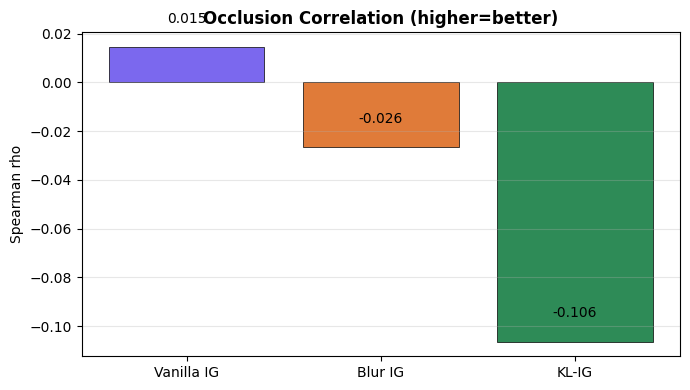

cat: Vanilla IG=0.189  Blur IG=-0.177  KL-IG=-0.139
dog: Vanilla IG=-0.072  Blur IG=-0.005  KL-IG=-0.050
tabby: Vanilla IG=-0.073  Blur IG=0.103  KL-IG=-0.130


In [34]:
def occlusion_map(model, x, target, ps=OCCLUSION_PATCH, stride=OCCLUSION_STRIDE):
    _, C, H, W = x.shape
    with torch.no_grad(): f0 = model(x)[0, target].item()
    hs = list(range(0, H - ps + 1, stride))
    ws = list(range(0, W - ps + 1, stride))
    om = np.zeros((len(hs), len(ws)))
    with torch.no_grad():
        for i, h in enumerate(hs):
            for j, w in enumerate(ws):
                m = x.clone(); m[0, :, h:h+ps, w:w+ps] = 0
                om[i, j] = f0 - model(m)[0, target].item()
    return om

def attr_to_grid(attr_map, ps, stride, H, W):
    a = attr_map.detach().cpu().abs().numpy()
    hs = list(range(0, H - ps + 1, stride))
    ws = list(range(0, W - ps + 1, stride))
    g = np.zeros((len(hs), len(ws)))
    for i, h in enumerate(hs):
        for j, w in enumerate(ws):
            g[i, j] = a[h:h+ps, w:w+ps].mean()
    return g

# Run per image
occ_corrs = defaultdict(dict)
for name, r in results.items():
    om = occlusion_map(model, r["x"], r["target"])
    _, _, H, W = r["x"].shape
    for method, amap in r["maps"].items():
        ag = attr_to_grid(amap, OCCLUSION_PATCH, OCCLUSION_STRIDE, H, W)
        rho, _ = stats.spearmanr(om.ravel(), ag.ravel())
        occ_corrs[name][method] = rho

# Aggregate bar chart
avg_occ = {m: np.mean([occ_corrs[n][m] for n in occ_corrs]) for m in methods}
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(methods, [avg_occ[m] for m in methods],
              color=[COLORS[m] for m in methods], edgecolor="black", lw=0.5)
ax.set_ylabel("Spearman rho"); ax.set_title("Occlusion Correlation (higher=better)", fontweight="bold")
ax.grid(axis="y", alpha=0.3)
for b, m in zip(bars, methods):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f"{avg_occ[m]:.3f}", ha="center", fontsize=10)
plt.tight_layout(); plt.show()

# Per-image
for name in occ_corrs:
    print(f"{name}: " + "  ".join(f"{m}={occ_corrs[name][m]:.3f}" for m in methods))

In [ ]:
def analyse_baselines(model, x, target):
    max_H = np.log(1000)
    with torch.no_grad():
        # Zero baseline
        z = torch.zeros_like(x)
        pz = model(z).softmax(-1)[0]
        Hz = -(pz * pz.log().clamp(min=-100)).sum().item()
        # Blur baseline
        bl = make_blur_baseline(x)
        pb = model(bl).softmax(-1)[0]
        Hb = -(pb * pb.log().clamp(min=-100)).sum().item()
        # N(0,1)
        noise = torch.randn(50, *x.squeeze(0).shape, device=DEVICE)
        pn = model(noise).softmax(-1).mean(0)
        Hn = -(pn * pn.log().clamp(min=-100)).sum().item()
    return {
        "Zero":  dict(p_target=pz[target].item(), entropy_ratio=Hz/max_H),
        "Blur":  dict(p_target=pb[target].item(), entropy_ratio=Hb/max_H),
        "N(0,1)": dict(p_target=pn[target].item(), entropy_ratio=Hn/max_H),
    }

x0 = r0["x"]
ba = analyse_baselines(model, x0, r0["target"])

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].imshow(denormalize(x0[0]).cpu().permute(1,2,0).numpy())
axes[0].set_title(f"Original\nP={r0['preds'][0][1]:.3f}", fontsize=10); axes[0].axis("off")

axes[1].imshow(denormalize(torch.zeros_like(x0)[0]).cpu().permute(1,2,0).numpy())
axes[1].set_title(f"Zero baseline\nP={ba['Zero']['p_target']:.4f} H/Hmax={ba['Zero']['entropy_ratio']:.2f}", fontsize=9)
axes[1].axis("off")

axes[2].imshow(denormalize(make_blur_baseline(x0)[0]).cpu().permute(1,2,0).numpy())
axes[2].set_title(f"Blur baseline\nP={ba['Blur']['p_target']:.4f} H/Hmax={ba['Blur']['entropy_ratio']:.2f}", fontsize=9)
axes[2].axis("off")

ns = torch.randn_like(x0)
axes[3].imshow(denormalize(ns[0]).cpu().permute(1,2,0).numpy().clip(0,1))
axes[3].set_title(f"N(0,1) sample\nE[P]={ba['N(0,1)']['p_target']:.4f} H/Hmax={ba['N(0,1)']['entropy_ratio']:.2f}", fontsize=9)
axes[3].axis("off")

fig.suptitle("Baseline Comparison: What Each Method Starts From", fontweight="bold")
plt.tight_layout(); plt.show()

print("\nIdeal reference: high H/Hmax (close to 1.0 = uniform), low P(target)")
for ref, vals in ba.items():
    print(f"  {ref:6s}: P(target)={vals['p_target']:.6f}  H/Hmax={vals['entropy_ratio']:.4f}")